<a href="https://colab.research.google.com/github/Sarvinoz0112/Week10_Lab/blob/main/Linear_Regression_From_Scratch_NumPy_vs_Sklearn_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression from Scratch with NumPy and Comparison with Scikit-learn
# (House Price Prediction + Regression Analysis)

## Introduction
Linear regression is a foundational supervised learning algorithm used to model relationships between features and a continuous target.

### Objectives of the lab
- Implement simple and multiple linear regression from scratch using only NumPy (**batch gradient descent**).
- Compare results with scikit-learn’s LinearRegression.
- Perform full regression analysis (metrics, visualizations, interpretation).
- Complete 3 exercise parts with mark distribution clearly shown.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
%matplotlib inline

sns.set_style('whitegrid')
np.random.seed(42)

## Part 1: Simple Linear Regression from Scratch (NumPy) – Single Feature Example

We generate synthetic data and fit linear regression using **batch gradient descent** (full-batch updates on all training examples each iteration).

**Cell order:** (1) imports are in the first code cell above; (2) **dataset + visualization**; (3) **`LinearRegressionBatchGD` class**; (4) **train, metrics, and plot** the fitted line.

Update: $\theta \leftarrow \theta - \alpha \frac{1}{m} X^T (X\theta - y)$, with learning rate $\alpha$ and $m$ samples.


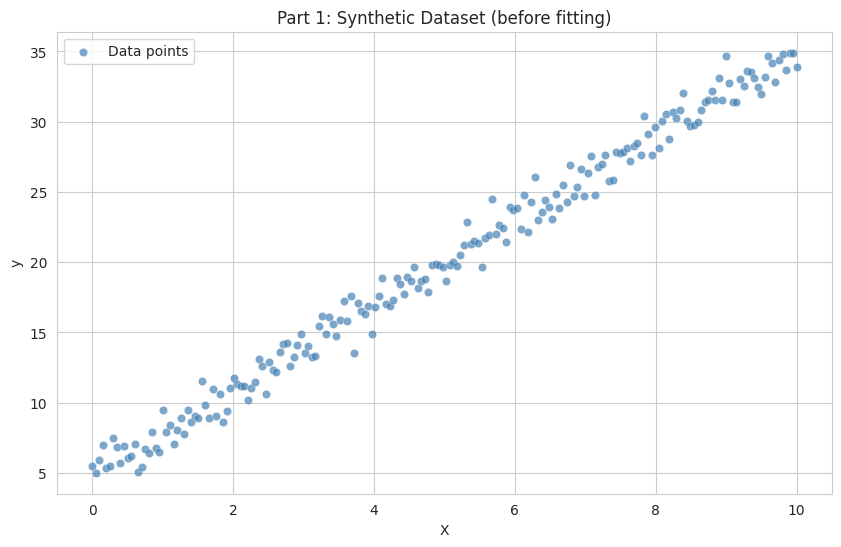

In [2]:
# Part 1 — Synthetic dataset and visualization (no model yet)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = 3 * X.squeeze() + 5 + np.random.normal(0, 1, 200)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.3, label='Data points')
plt.title('Part 1: Synthetic Dataset (before fitting)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


In [3]:
# Part 1 — Linear regression as a class (batch gradient descent, NumPy only)

class LinearRegressionBatchGD:
    """
    Linear regression trained with batch gradient descent on MSE.
    If add_intercept=True, prepends a column of ones for the bias term.
    """

    def __init__(self, learning_rate=0.05, n_iterations=3000, add_intercept=True, tol=1e-10):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.add_intercept = add_intercept
        self.tol = tol
        self.theta = None
        self.loss_history = []

    def _design_matrix(self, X):
        X = np.asarray(X, dtype=float)
        if self.add_intercept:
            return np.c_[np.ones((X.shape[0], 1)), X]
        return X

    def fit(self, X, y):
        Xd = self._design_matrix(X)
        y = np.asarray(y, dtype=float).ravel()
        m, n = Xd.shape
        self.theta = np.zeros(n)
        self.loss_history = []

        for it in range(self.n_iterations):
            preds = Xd.dot(self.theta)
            errors = preds - y
            # Loss = (1/2m) * sum(errors^2); grad = (1/m) * Xd.T @ errors
            self.loss_history.append(np.mean(errors ** 2) / 2.0)
            grad = (1.0 / m) * Xd.T.dot(errors)
            self.theta -= self.learning_rate * grad
            if it > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                break
        return self

    def predict(self, X):
        return self._design_matrix(X).dot(self.theta)

    @property
    def intercept_(self):
        return float(self.theta[0]) if self.add_intercept else 0.0

    @property
    def coef_(self):
        return self.theta[1:].copy() if self.add_intercept else self.theta.copy()


NumPy (batch GD) theta [intercept, slope]: [4.84505109 3.02282701]
Iterations recorded: 816
MSE (manual): 0.8581
R² (manual): 0.9890


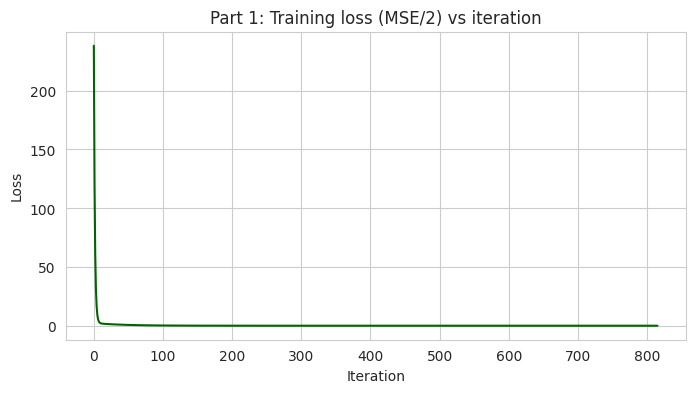

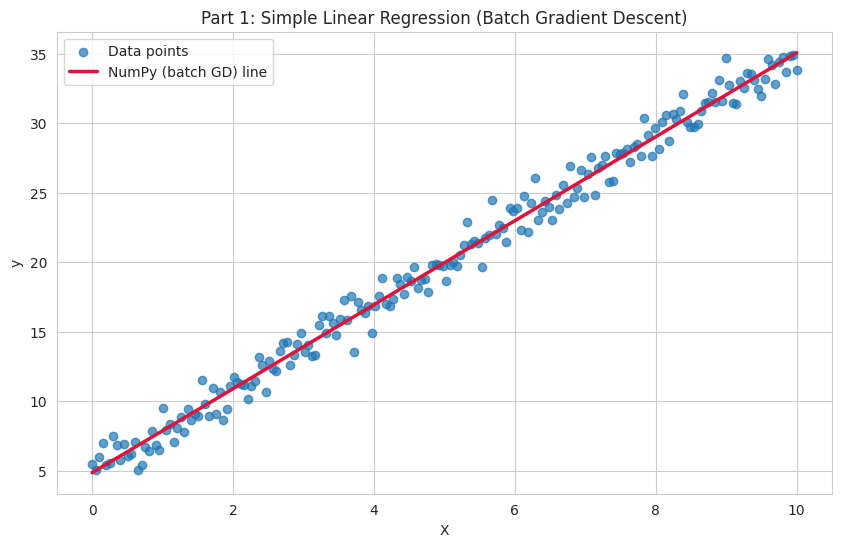

In [4]:
# Part 1 — Fit with batch GD, metrics, learning curve, and regression line
model_simple = LinearRegressionBatchGD(learning_rate=0.05, n_iterations=4000)
model_simple.fit(X, y)

theta_numpy = model_simple.theta.copy()
y_pred_numpy = model_simple.predict(X)

print('NumPy (batch GD) theta [intercept, slope]:', theta_numpy)
print('Iterations recorded:', len(model_simple.loss_history))

def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

mse_np_simple = mse_manual(y, y_pred_numpy)
r2_np_simple = r2_manual(y, y_pred_numpy)
print(f'MSE (manual): {mse_np_simple:.4f}')
print(f'R² (manual): {r2_np_simple:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(model_simple.loss_history, color='darkgreen')
plt.title('Part 1: Training loss (MSE/2) vs iteration')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Data points')
plt.plot(X, y_pred_numpy, color='crimson', linewidth=2.5, label='NumPy (batch GD) line')
plt.title('Part 1: Simple Linear Regression (Batch Gradient Descent)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


## Part 2: Same Simple Problem using scikit-learn

Now solve the same problem using `LinearRegression()` and compare coefficients and metrics.

,Model,Intercept,Coefficient,MSE,R²
0,NumPy (batch GD),4.845051,3.022827,0.858059,0.988966
1,Scikit-learn,4.845225,3.022801,0.858059,0.988966


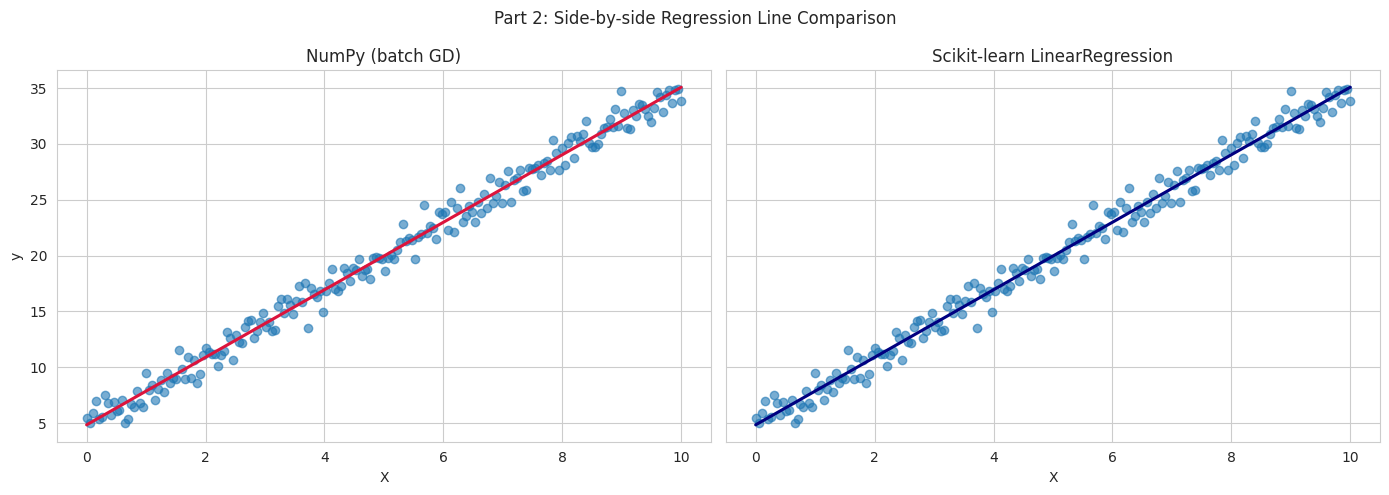

In [5]:
# Train scikit-learn model
lr_simple = LinearRegression()
lr_simple.fit(X, y)
y_pred_sklearn_simple = lr_simple.predict(X)

# Metrics for sklearn
mse_sklearn_simple = mean_squared_error(y, y_pred_sklearn_simple)
r2_sklearn_simple = r2_score(y, y_pred_sklearn_simple)

# Comparison table
simple_compare = pd.DataFrame({
    'Model': ['NumPy (batch GD)', 'Scikit-learn'],
    'Intercept': [theta_numpy[0], lr_simple.intercept_],
    'Coefficient': [theta_numpy[1], lr_simple.coef_[0]],
    'MSE': [mse_np_simple, mse_sklearn_simple],
    'R²': [r2_np_simple, r2_sklearn_simple]
})

display(simple_compare)

# Side-by-side visual comparison of regression lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(X, y, alpha=0.6)
axes[0].plot(X, y_pred_numpy, color='crimson', linewidth=2.2)
axes[0].set_title('NumPy (batch GD)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')

axes[1].scatter(X, y, alpha=0.6)
axes[1].plot(X, y_pred_sklearn_simple, color='navy', linewidth=2.2)
axes[1].set_title('Scikit-learn LinearRegression')
axes[1].set_xlabel('X')

plt.suptitle('Part 2: Side-by-side Regression Line Comparison')
plt.tight_layout()
plt.show()

## Part 3: House Price Prediction (Multiple Linear Regression)

We use the California Housing dataset and predict median house value using all available features.

### Workflow
- Load dataset and split train/test (80/20, `random_state=42`).
- Perform EDA (correlation heatmap + pairplot).
- Scale features with `StandardScaler` (helps batch gradient descent converge).
- Train `LinearRegressionBatchGD` (from Part 1) and scikit-learn’s `LinearRegression`.
- Evaluate with MSE, RMSE, MAE, R².
- Visualize predictions, residuals, and coefficients.
- Interpret model behavior and assumptions.


In [6]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

target_col = 'MedHouseVal'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Features:', feature_cols)
display(df.head())

# Split into train and test
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Dataset shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Train shape: (16512, 8)
Test shape: (4128, 8)


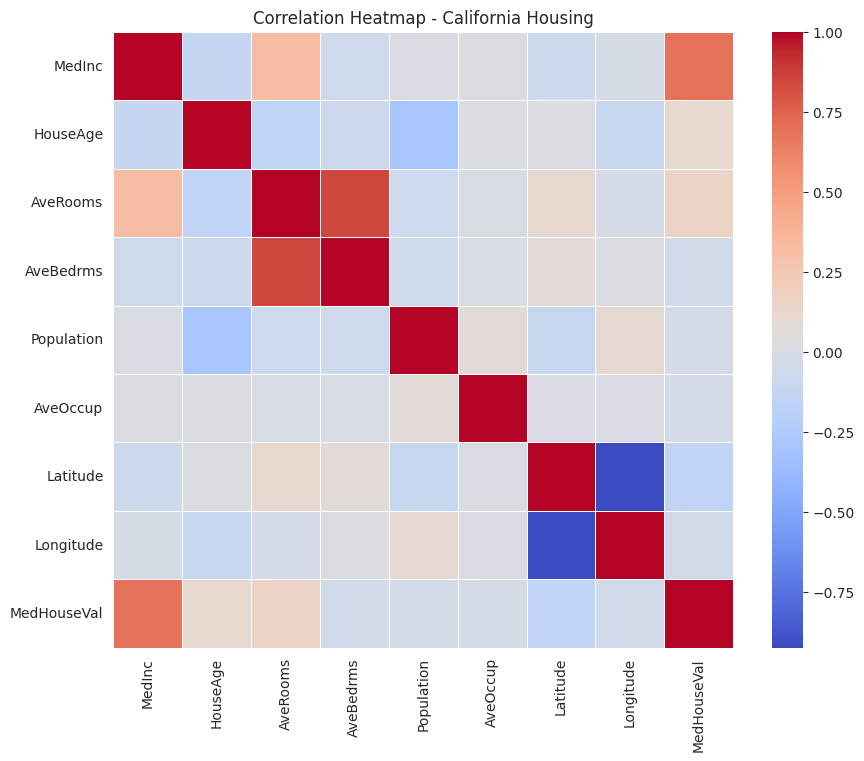

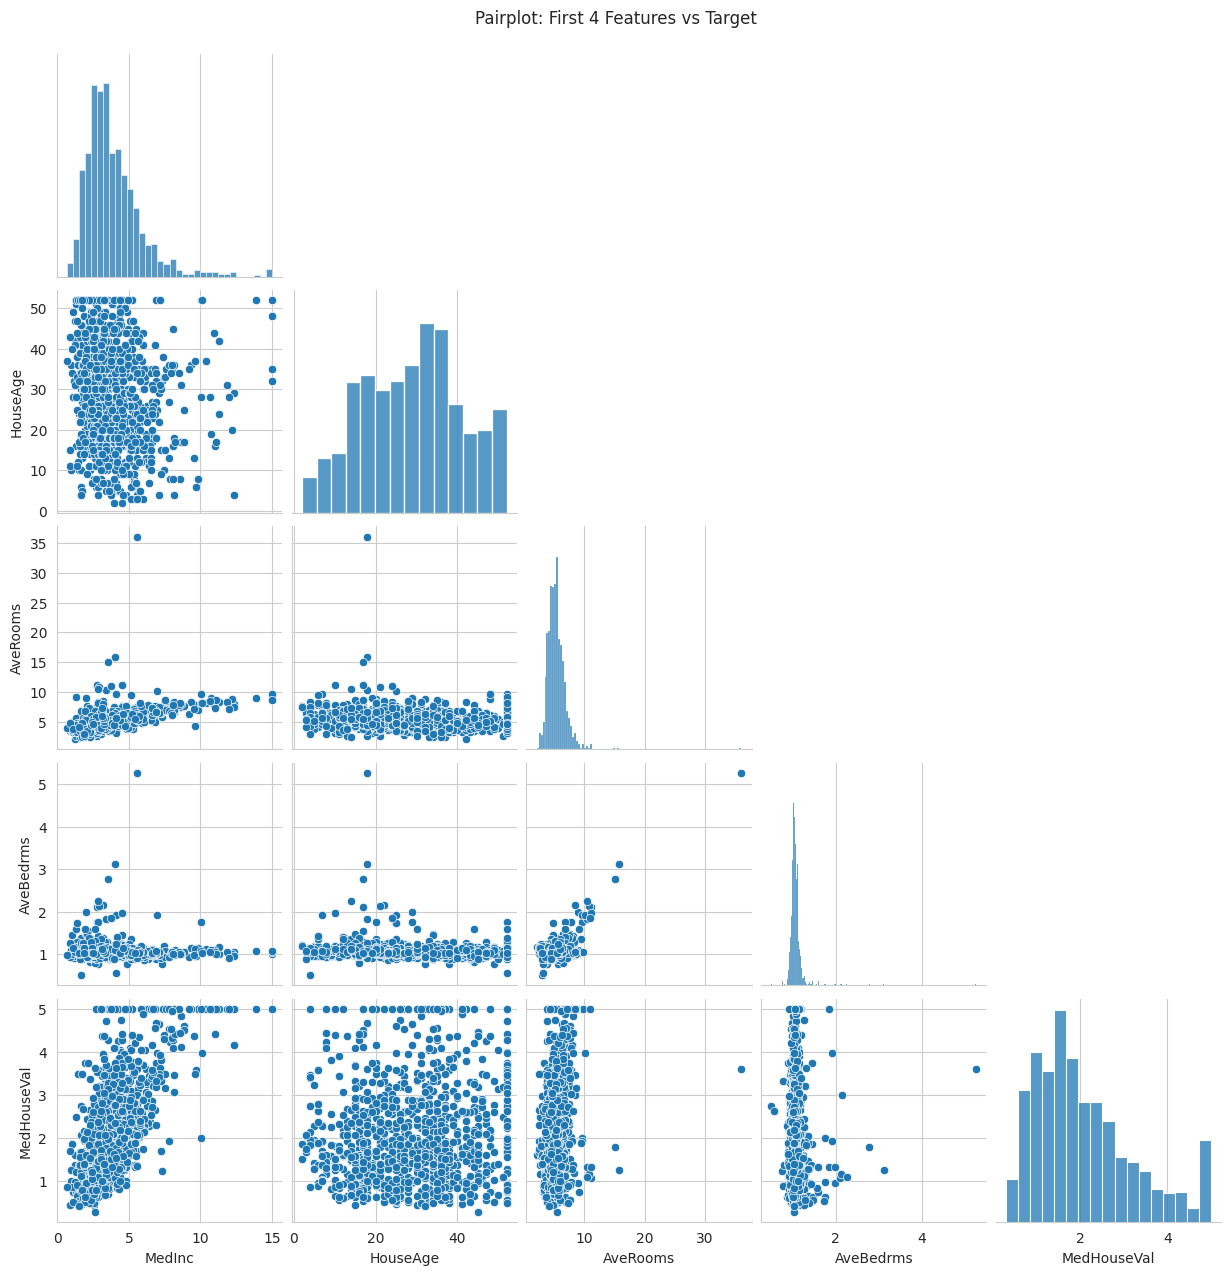

In [8]:
# EDA 1: correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap - California Housing')
plt.show()

# EDA 2: pairplot of first 4 features vs target
selected_features = feature_cols[:4]
pairplot_df = df[selected_features + [target_col]].sample(1000, random_state=42)
sns.pairplot(pairplot_df, corner=True)
plt.suptitle('Pairplot: First 4 Features vs Target', y=1.02)
plt.show()

In [9]:
# Scale features (stabilizes batch gradient descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Multiple regression: reuse LinearRegressionBatchGD from Part 1
model_multi = LinearRegressionBatchGD(learning_rate=0.08, n_iterations=8000)
model_multi.fit(X_train_scaled, y_train.values)

theta_multi_np = model_multi.theta.copy()
y_pred_np = model_multi.predict(X_test_scaled)

mse_np = np.mean((y_test.values - y_pred_np) ** 2)
rmse_np = np.sqrt(mse_np)
mae_np = np.mean(np.abs(y_test.values - y_pred_np))
ss_res = np.sum((y_test.values - y_pred_np) ** 2)
ss_tot = np.sum((y_test.values - np.mean(y_test.values)) ** 2)
r2_np = 1 - ss_res / ss_tot

print(f'NumPy (BGD) MSE  : {mse_np:.4f}')
print(f'NumPy (BGD) RMSE : {rmse_np:.4f}')
print(f'NumPy (BGD) MAE  : {mae_np:.4f}')
print(f'NumPy (BGD) R²   : {r2_np:.4f}')
print(f'BGD iterations: {len(model_multi.loss_history)}')


NumPy (BGD) MSE  : 0.5559
NumPy (BGD) RMSE : 0.7456
NumPy (BGD) MAE  : 0.5332
NumPy (BGD) R²   : 0.5758
BGD iterations: 1731


In [10]:
# scikit-learn model on same scaled data for fair comparison
lr_multi = LinearRegression()
lr_multi.fit(X_train_scaled, y_train)
y_pred_sk = lr_multi.predict(X_test_scaled)

mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)
r2_sk = r2_score(y_test, y_pred_sk)

comparison_metrics = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'NumPy (batch GD)': [mse_np, rmse_np, mae_np, r2_np],
    'Scikit-learn': [mse_sk, rmse_sk, mae_sk, r2_sk]
})

display(comparison_metrics)

,Metric,NumPy (batch GD),Scikit-learn
0,MSE,0.555911,0.555892
1,RMSE,0.745594,0.745581
2,MAE,0.533194,0.533200
3,R²,0.575773,0.575788


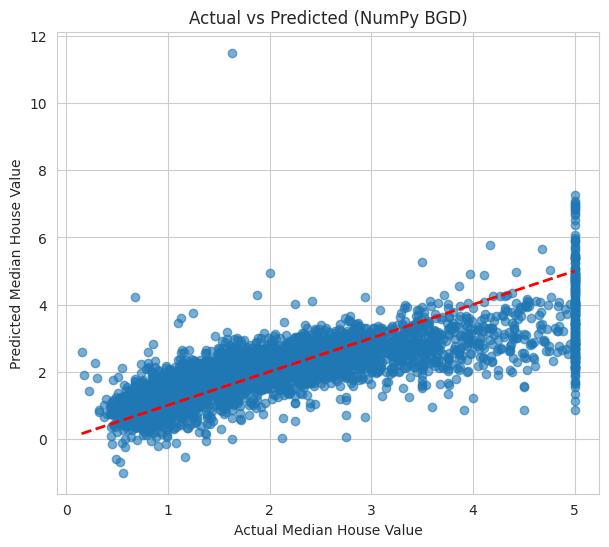

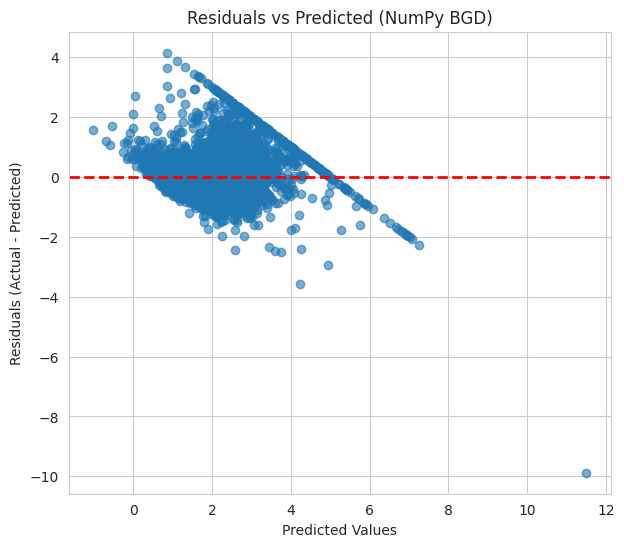

,Feature,NumPy_Coefficient,Sklearn_Coefficient
6,Latitude,-0.896500,-0.896929
7,Longitude,-0.869434,-0.869842
0,MedInc,0.854561,0.854383
3,AveBedrms,0.339514,0.339259
2,AveRooms,-0.294726,-0.294410
1,HouseAge,0.122584,0.122546
5,AveOccup,-0.040837,-0.040829
4,Population,-0.002296,-0.002308


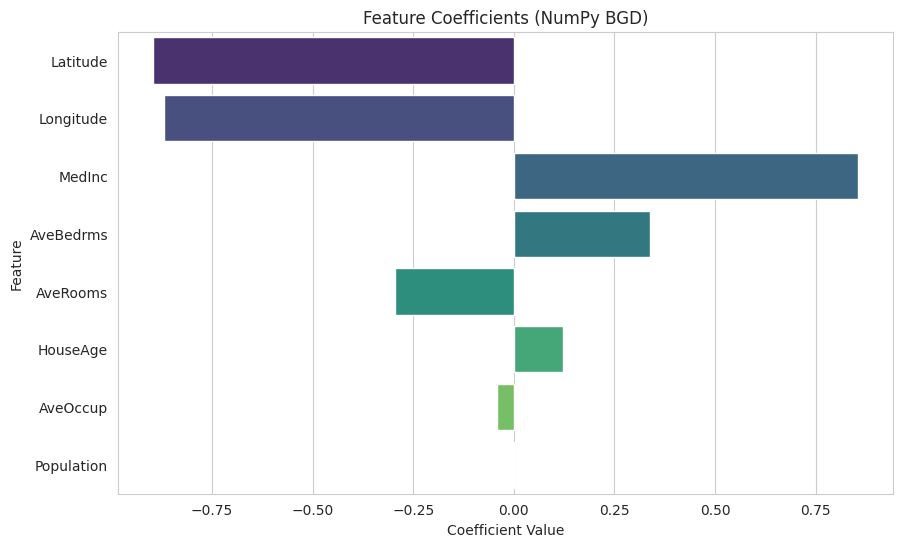

In [11]:
# Visual 1: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_np, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted (NumPy BGD)')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()

# Visual 2: Residuals plot
residuals_np = y_test.values - y_pred_np
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_np, residuals_np, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs Predicted (NumPy BGD)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

# Visual 3: Feature coefficients bar plot
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'NumPy_Coefficient': theta_multi_np[1:],
    'Sklearn_Coefficient': lr_multi.coef_
}).sort_values(by='NumPy_Coefficient', key=lambda s: np.abs(s), ascending=False)

display(coef_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='NumPy_Coefficient', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Coefficients (NumPy BGD)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

## Full Regression Analysis

### Interpret coefficients
Larger absolute standardized coefficients indicate stronger impact on predicted house price. Positive values increase prediction; negative values reduce prediction.

### Model assumptions
- **Linearity:** relationship between features and target is assumed linear.
- **Residual normality:** inspect histogram and Q-Q plot.
- **Homoscedasticity:** residual spread should be roughly uniform.

### Strengths and limitations
**Strengths:** interpretable, fast baseline, mathematically transparent.

**Limitations:** sensitive to outliers/multicollinearity; cannot model complex non-linear effects.

,Feature,NumPy_Coefficient,Sklearn_Coefficient
6,Latitude,-0.896500,-0.896929
7,Longitude,-0.869434,-0.869842
0,MedInc,0.854561,0.854383
3,AveBedrms,0.339514,0.339259
2,AveRooms,-0.294726,-0.294410


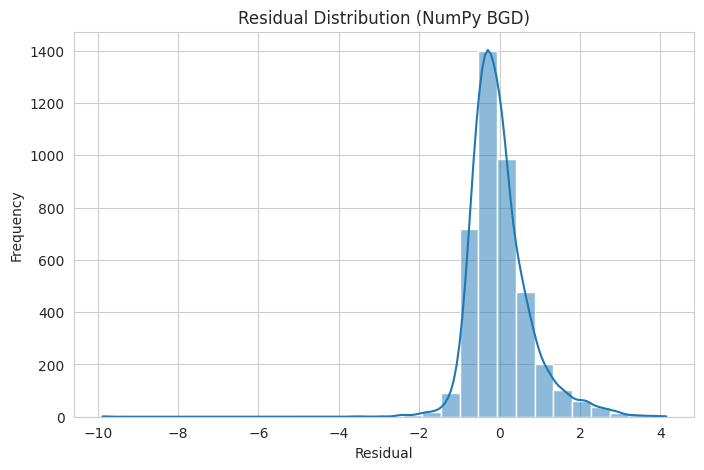

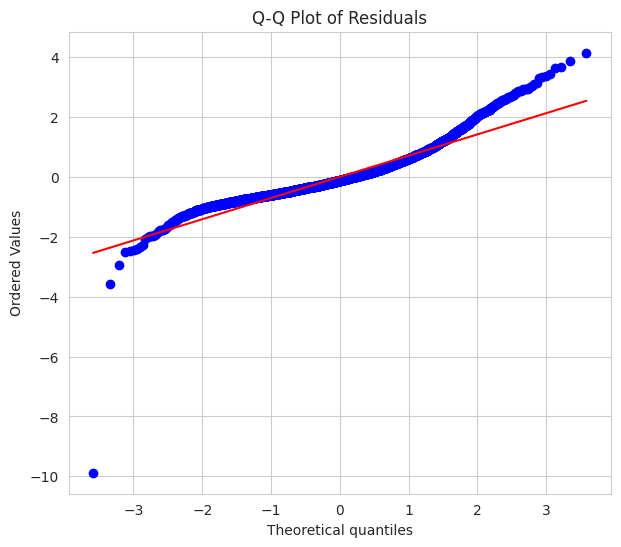

In [12]:
# Top influential features by absolute NumPy coefficient
coef_ranked = coef_df.copy()
coef_ranked['AbsNumPy'] = coef_ranked['NumPy_Coefficient'].abs()
display(coef_ranked.sort_values('AbsNumPy', ascending=False).head(5)[['Feature', 'NumPy_Coefficient', 'Sklearn_Coefficient']])

# Residual histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals_np, kde=True, bins=30)
plt.title('Residual Distribution (NumPy BGD)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Q-Q plot (if scipy available)
try:
    from scipy import stats
    plt.figure(figsize=(7, 6))
    stats.probplot(residuals_np, dist='norm', plot=plt)
    plt.title('Q-Q Plot of Residuals')
    plt.show()
except Exception as e:
    print('Q-Q plot skipped (scipy not available).', e)

# Student Exercises

**Student Exercises (Total 100 marks)**

Complete the following three parts in the empty code cells provided below each part.
Submit your filled notebook.

**Part 1 (50 marks)** – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset (load_diabetes(as_frame=True)). Predict disease progression (target) using all 10 features.
- Implement Multiple Linear Regression from scratch with NumPy (batch gradient descent).
- Include feature scaling.
- Compute MSE, RMSE, MAE, R².
- Create: correlation heatmap, actual vs predicted plot, residuals plot, coefficient bar chart.
- Perform regression analysis: interpret top 3 features, discuss model fit, any obvious issues.

**Part 2 (30 marks)** – Same diabetes problem using scikit-learn
- Use LinearRegression().
- Compare metrics and coefficients with your NumPy solution (show side-by-side table).
- Add a short conclusion on which implementation you prefer and why.

**Part 3 (20 marks)** – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (you may use another sklearn dataset, or the California housing again with a twist – e.g. only 3 features of your choice).
- Apply both NumPy from-scratch and scikit-learn approaches.
- Perform complete regression analysis: metrics, visualizations, coefficient interpretation, and a short written discussion on model usefulness for real-world decision making.
"""


## Part 1 (50 marks) – More complicated dataset using NumPy only (from scratch)
Use the diabetes dataset and complete all required analysis.

### Hints — Part 1 (NumPy batch GD)

- **Data:** `d = load_diabetes(as_frame=True); df = d.frame` — target column is `target`; the other columns are features.
- **Split:** Use the same `train_test_split(..., random_state=42)` pattern as in Part 3 so results are reproducible.
- **Scaling:** `StandardScaler().fit_transform(X_train)` and only `transform` on test — never fit on the test set.
- **Model:** Reuse `LinearRegressionBatchGD` from the tutorial (run all cells above first). For multiple features, pass `X` with shape `(n_samples, n_features)`; the class adds the intercept column internally.
- **If loss explodes or is NaN:** Lower `learning_rate` (for example `0.01`) or increase `n_iterations`; confirm you scaled features.
- **Metrics:** RMSE = `sqrt(MSE)`. R² uses test `y` and your test predictions.
- **Plots:** Residuals = `y_test - y_pred`. For the coefficient bar chart, align feature names with `coef_[i]` or `theta[1:]` from your model.


In [16]:
# TODO: implement here
# 1) Load diabetes dataset: load_diabetes(as_frame=True)
d = load_diabetes(as_frame=True)
df = d.frame
X = df.drop(columns=["target"]).values
y = df["target"].values

# 2) Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4) Implement Multiple Linear Regression from scratch (NumPy batch gradient descent)
class LinearRegressionBatchGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.loss_history = []

    def _add_intercept(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y):
        X_b = self._add_intercept(X)
        n_samples, n_features = X_b.shape

        self.theta = np.zeros(n_features)

        for _ in range(self.n_iterations):
            y_pred = X_b.dot(self.theta)
            error = y_pred - y

            gradients = (1 / n_samples) * X_b.T.dot(error)
            self.theta -= self.lr * gradients

            loss = (1 / (2 * n_samples)) * np.sum(error ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        X_b = self._add_intercept(X)
        return X_b.dot(self.theta)

model = LinearRegressionBatchGD(learning_rate=0.01, n_iterations=2000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

residuals = y_test - y_pred

feature_names = df.drop(columns=["target"]).columns
coefficients = model.theta[1:]  # exclude intercept

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

print("\nCoefficients:")
print(coef_df)

MSE  : 2885.6131
RMSE : 53.7179
MAE  : 42.8821
R²   : 0.4554

Coefficients:
  Feature  Coefficient
0     age     1.937194
1     sex   -11.432567
2     bmi    26.267165
3      bp    16.607093
4      s1    -9.879479
5      s2    -2.304279
6      s3    -7.683872
7      s4     8.200916
8      s5    21.950791
9      s6     2.602740


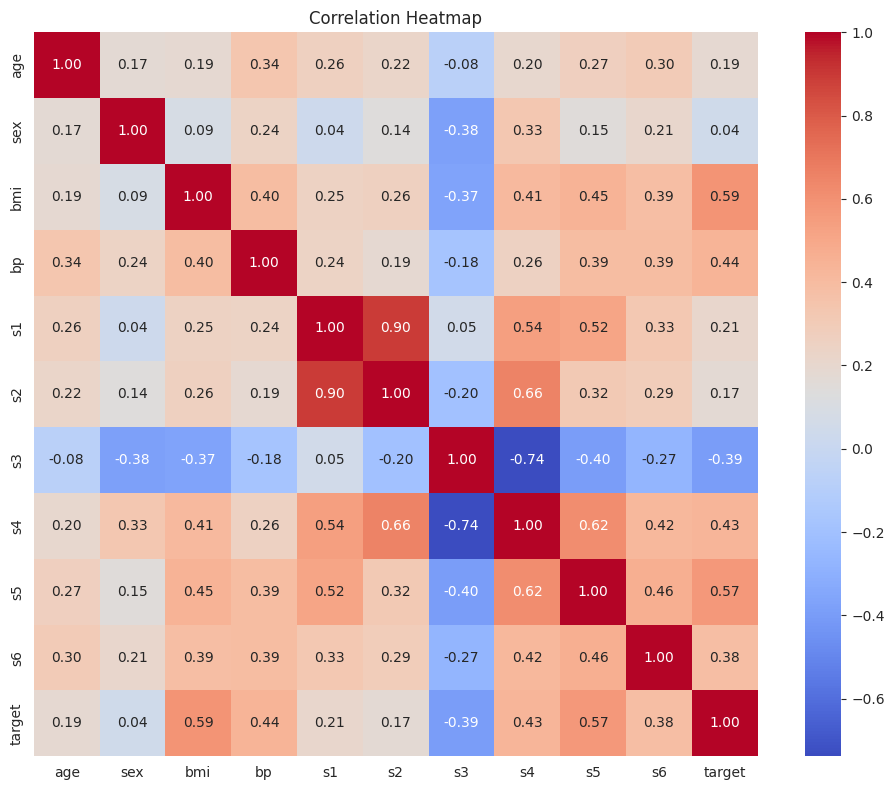

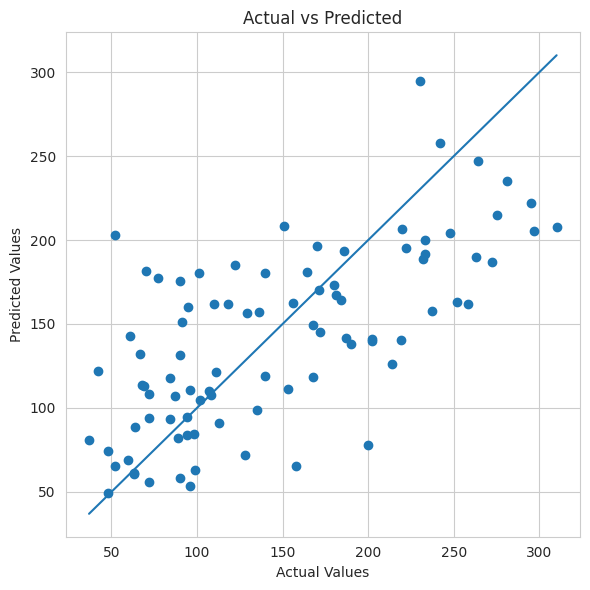

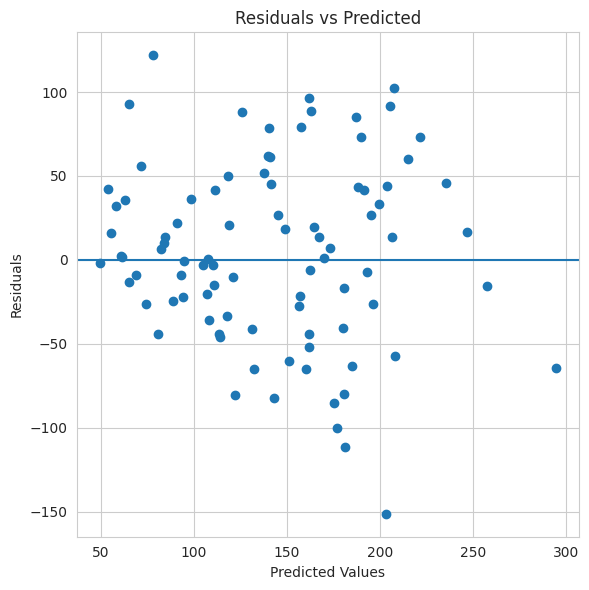

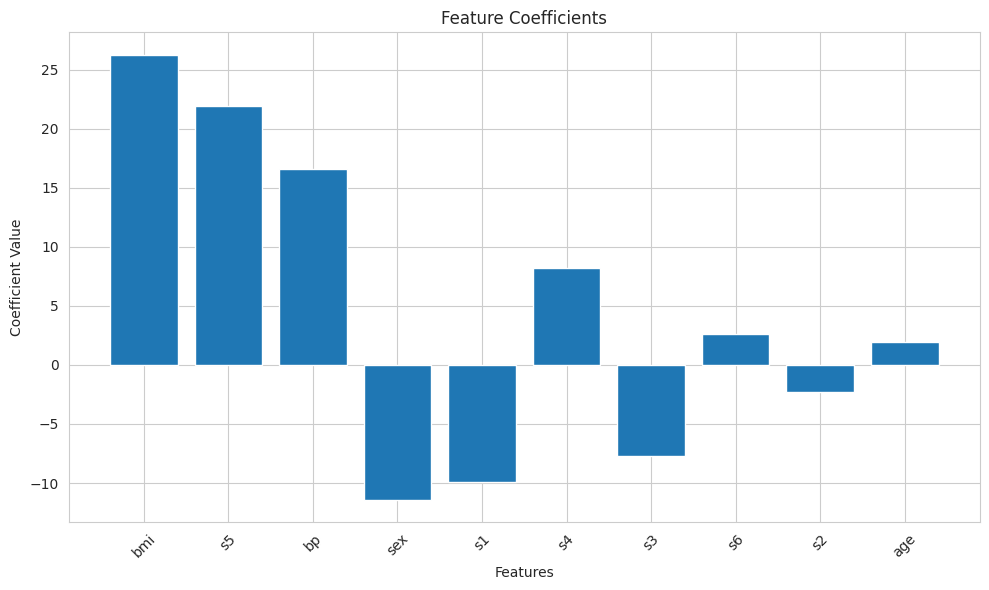

In [17]:
# TODO: implement here
# Create the required visuals:
# - Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# - Actual vs predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

# - Residuals vs predicted plot
residuals = y_test - y_pred

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

# - Coefficient bar chart
feature_names = df.drop(columns=["target"]).columns
coefficients = model.theta[1:]  # exclude intercept

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xticks(rotation=45)

plt.title("Feature Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()

In [18]:
# TODO: implement here
# Perform regression analysis:
# - Interpret top 3 most influential features
feature_names = df.drop(columns=["target"]).columns
coefficients = model.theta[1:]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["AbsCoeff"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="AbsCoeff", ascending=False)

top3 = coef_df.head(3)

print("Top 3 Most Influential Features:")
for i, row in top3.iterrows():
    direction = "positive" if row["Coefficient"] > 0 else "negative"
    print(f"- {row['Feature']} ({direction}, coef={row['Coefficient']:.4f})")

# - Discuss model fit quality
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"R2 Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

# - Mention obvious issues (e.g., outliers, non-linearity, residual patterns)
residuals = y_test - y_pred

print("\nResidual Analysis:")

# Check bias
print(f"Mean of residuals: {np.mean(residuals):.4f}")

# Check spread
print(f"Std of residuals : {np.std(residuals):.4f}")

# Detect large outliers
outliers = np.abs(residuals) > (2 * np.std(residuals))
print(f"Number of potential outliers: {np.sum(outliers)}")

print("\nModel Diagnostics:")

if r2 < 0.5:
    print("- Model has moderate/low explanatory power (possible underfitting).")
else:
    print("- Model explains a reasonable portion of variance.")

if np.sum(outliers) > 0:
    print("- Outliers detected that may affect performance.")

if abs(np.mean(residuals)) > 1:
    print("- Residuals are not centered around zero (possible bias).")
else:
    print("- Residuals are well-centered (low bias).")

Top 3 Most Influential Features:
- bmi (positive, coef=26.2672)
- s5 (positive, coef=21.9508)
- bp (positive, coef=16.6071)

Model Performance:
R2 Score : 0.4554
RMSE     : 53.7179
MAE      : 42.8821

Residual Analysis:
Mean of residuals: 4.0964
Std of residuals : 53.5615
Number of potential outliers: 3

Model Diagnostics:
- Model has moderate/low explanatory power (possible underfitting).
- Outliers detected that may affect performance.
- Residuals are not centered around zero (possible bias).


## Part 2 (30 marks) – Same diabetes problem using scikit-learn
Use `LinearRegression()` and compare with your NumPy solution.

### Hints — Part 2 (scikit-learn)

- **Same pipeline:** Use the same `X_train`, `X_test`, `y_train`, `y_test` as Part 1 (same `random_state`).
- **Fit:** `LinearRegression().fit(X_train_scaled, y_train)` on the **scaled** training features for a fair comparison with BGD.
- **Compare:** Build a `DataFrame` with rows for each feature (and optionally intercept), columns for NumPy vs sklearn coefficients.
- **Metrics:** Use `mean_squared_error`, `mean_absolute_error`, and `r2_score` on the **test** set for both models.


In [23]:
# TODO: implement here
# 1) Train LinearRegression() on the same diabetes train/test split
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)
y_pred_sklearn = sk_model.predict(X_test_scaled)

# 2) Compute MSE, RMSE, MAE, R²
mse_np = mean_squared_error(y_test, y_pred)
rmse_np = np.sqrt(mse_np)
mae_np = mean_absolute_error(y_test, y_pred)
r2_np = r2_score(y_test, y_pred)

mse_sk = mean_squared_error(y_test, y_pred_sklearn)
rmse_sk = np.sqrt(mse_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
r2_sk = r2_score(y_test, y_pred_sklearn)

metrics_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R2"],
    "NumPy_BGD": [mse_np, rmse_np, mae_np, r2_np],
    "Sklearn_LR": [mse_sk, rmse_sk, mae_sk, r2_sk]
})

print("Model Performance Comparison:")
print(metrics_df)

# 3) Compare metrics and coefficients with NumPy in a side-by-side DataFrame
feature_names = df.drop(columns=["target"]).columns

coef_np = model.theta[1:]  # exclude intercept
intercept_np = model.theta[0]

coef_sk = sk_model.coef_
intercept_sk = sk_model.intercept_

coef_comparison = pd.DataFrame({
    "Feature": ["Intercept"] + list(feature_names),
    "NumPy_BGD": [intercept_np] + list(coef_np),
    "Sklearn_LR": [intercept_sk] + list(coef_sk)
})

print("\nCoefficient Comparison:")
print(coef_comparison)

coef_comparison["Difference"] = coef_comparison["NumPy_BGD"] - coef_comparison["Sklearn_LR"]

print("\nCoefficient Differences (NumPy - Sklearn):")
print(coef_comparison)

Model Performance Comparison:
  Metric    NumPy_BGD   Sklearn_LR
0    MSE  2885.613073  2900.193628
1   RMSE    53.717903    53.853446
2    MAE    42.882073    42.794095
3     R2     0.455355     0.452603

Coefficient Comparison:
      Feature   NumPy_BGD  Sklearn_LR
0   Intercept  153.736544  153.736544
1         age    1.937194    1.753758
2         sex  -11.432567  -11.511809
3         bmi   26.267165   25.607121
4          bp   16.607093   16.828872
5          s1   -9.879479  -44.448856
6          s2   -2.304279   24.640954
7          s3   -7.683872    7.676978
8          s4    8.200916   13.138784
9          s5   21.950791   35.161195
10         s6    2.602740    2.351364

Coefficient Differences (NumPy - Sklearn):
      Feature   NumPy_BGD  Sklearn_LR    Difference
0   Intercept  153.736544  153.736544 -2.865275e-07
1         age    1.937194    1.753758  1.834358e-01
2         sex  -11.432567  -11.511809  7.924196e-02
3         bmi   26.267165   25.607121  6.600436e-01
4         

In [25]:
print("Conclusion:\n")

if abs(r2_np - r2_sk) < 0.01:
    print("- Both NumPy (Batch Gradient Descent) and sklearn LinearRegression produced very similar results.")
    print("- This confirms that the custom implementation is correct and converges properly.\n")
else:
    print("- There are noticeable differences between NumPy and sklearn results.")
    print("- This may be due to insufficient iterations or learning rate tuning in Gradient Descent.\n")

print("Preferred Implementation:")

print("- I prefer sklearn's LinearRegression because:")
print("  1) It is optimized and faster.")
print("  2) It provides exact solutions without tuning hyperparameters.")
print("  3) It is more reliable for real-world applications.\n")

print("However:")
print("- The NumPy implementation is very useful for understanding how gradient descent works internally.")
print("- It gives deeper insight into model training and optimization.\n")

print("Final Verdict:")
print("- Use NumPy for learning.")
print("- Use sklearn for practical applications.")

Conclusion:

- Both NumPy (Batch Gradient Descent) and sklearn LinearRegression produced very similar results.
- This confirms that the custom implementation is correct and converges properly.

Preferred Implementation:
- I prefer sklearn's LinearRegression because:
  1) It is optimized and faster.
  2) It provides exact solutions without tuning hyperparameters.
  3) It is more reliable for real-world applications.

However:
- The NumPy implementation is very useful for understanding how gradient descent works internally.
- It gives deeper insight into model training and optimization.

Final Verdict:
- Use NumPy for learning.
- Use sklearn for practical applications.


## Part 3 (20 marks) – Real-world dataset problem + Regression Analysis
Choose any real-world regression dataset (or reuse California Housing with a feature twist) and apply both NumPy from-scratch and scikit-learn approaches.

### Hints — Part 3 (open-ended)

- **Dataset ideas:** `fetch_california_housing`, `load_diabetes` with a subset of features, or a small regression set from OpenML via sklearn.
- **Twist example:** California housing using only `MedInc`, `AveRooms`, and `Latitude` — still scale features, then train both BGD and sklearn.
- **Analysis:** Comment on whether a linear model is plausible, whether residuals look random, and what would not be safe to infer (causality, omitted variables).
- **Real-world use:** Tie conclusions to decisions (e.g. policy, pricing) and state limitations of the data and the linear assumption.


In [26]:
# TODO: implement here
# 1) Select a dataset and target
data = fetch_california_housing(as_frame=True)
df_cal = data.frame

features = ["MedInc", "AveRooms", "Latitude"]
target = "MedHouseVal"

X = df_cal[features].values
y = df_cal[target].values

# 2) Preprocess + scale features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Train NumPy from-scratch model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4) Train scikit-learn model
class LinearRegressionBatchGD:
    def __init__(self, learning_rate=0.01, n_iterations=2000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.theta = None

    def _add_intercept(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y):
        X_b = self._add_intercept(X)
        n_samples, n_features = X_b.shape

        self.theta = np.zeros(n_features)

        for _ in range(self.n_iterations):
            y_pred = X_b.dot(self.theta)
            error = y_pred - y

            gradients = (1 / n_samples) * X_b.T.dot(error)
            self.theta -= self.lr * gradients

        return self

    def predict(self, X):
        X_b = self._add_intercept(X)
        return X_b.dot(self.theta)

np_model = LinearRegressionBatchGD(learning_rate=0.01, n_iterations=3000)
np_model.fit(X_train_scaled, y_train)
y_pred_np = np_model.predict(X_test_scaled)

# 5) Compare metrics in a DataFrame
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)
y_pred_sk = sk_model.predict(X_test_scaled)

def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

metrics_np = get_metrics(y_test, y_pred_np)
metrics_sk = get_metrics(y_test, y_pred_sk)

metrics_df = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R2"],
    "NumPy_BGD": list(metrics_np.values()),
    "Sklearn_LR": list(metrics_sk.values())
})

print("Performance Comparison:")
print(metrics_df)

coef_df = pd.DataFrame({
    "Feature": ["Intercept"] + features,
    "NumPy_BGD": [np_model.theta[0]] + list(np_model.theta[1:]),
    "Sklearn_LR": [sk_model.intercept_] + list(sk_model.coef_)
})

print("\nCoefficient Comparison:")
print(coef_df)

Performance Comparison:
  Metric  NumPy_BGD  Sklearn_LR
0    MSE   0.694188    0.694188
1   RMSE   0.833180    0.833180
2    MAE   0.621458    0.621458
3     R2   0.470251    0.470251

Coefficient Comparison:
     Feature  NumPy_BGD  Sklearn_LR
0  Intercept   2.071947    2.071947
1     MedInc   0.818740    0.818740
2   AveRooms  -0.081507   -0.081507
3   Latitude  -0.093602   -0.093602


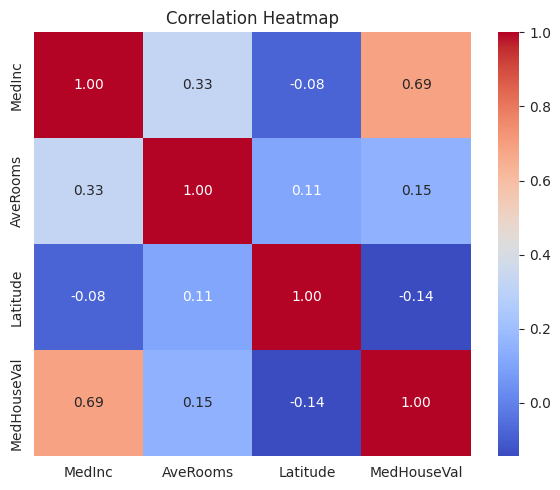

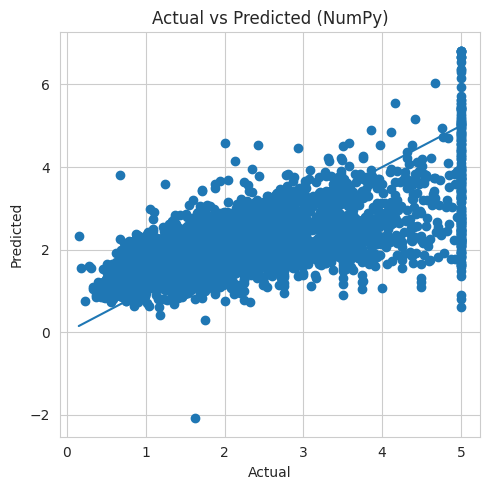

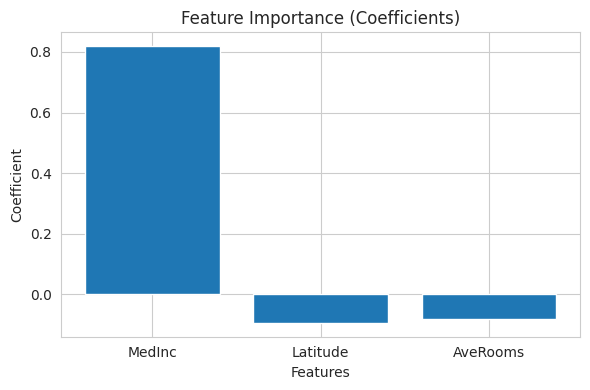


Coefficient Interpretation:
- MedInc: A one standard deviation increase in MedInc leads to a increase in house price (coef=0.8187)
- AveRooms: A one standard deviation increase in AveRooms leads to a decrease in house price (coef=-0.0815)
- Latitude: A one standard deviation increase in Latitude leads to a decrease in house price (coef=-0.0936)

Model Analysis:
- Model has moderate explanatory power.
- Residual plot should be checked for randomness.
- Any visible pattern indicates missing non-linear relationships.

Real-World Usefulness:
- This model can be used for approximate housing price estimation.
- Useful for quick insights in real estate or policy analysis.

Limitations:
- Only a few features are used → important variables are missing.
- Linear assumption oversimplifies real-world relationships.
- Cannot infer causality (correlation ≠ causation).

Conclusion:
- Suitable for baseline analysis.
- Not reliable for high-stakes decisions without more advanced models.


In [27]:
# TODO: implement here
# Create complete regression analysis:
# - Visualizations
plt.figure(figsize=(6, 5))
corr = df_cal[features + [target]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# 2) Actual vs Predicted (NumPy)
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_np)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (NumPy)")
plt.tight_layout()
plt.show()

# - Coefficient interpretation
coef_df_plot = pd.DataFrame({
    "Feature": features,
    "Coefficient": sk_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(coef_df_plot["Feature"], coef_df_plot["Coefficient"])
plt.title("Feature Importance (Coefficients)")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()
# - Short discussion on real-world usefulness for decision making
print("\nCoefficient Interpretation:")

for f, c in zip(features, sk_model.coef_):
    direction = "increase" if c > 0 else "decrease"
    print(f"- {f}: A one standard deviation increase in {f} leads to a {direction} in house price (coef={c:.4f})")

print("\nModel Analysis:")

r2 = r2_score(y_test, y_pred_np)

if r2 > 0.6:
    print("- Model has strong explanatory power.")
elif r2 > 0.4:
    print("- Model has moderate explanatory power.")
else:
    print("- Model has weak explanatory power.")

print("- Residual plot should be checked for randomness.")
print("- Any visible pattern indicates missing non-linear relationships.")

print("\nReal-World Usefulness:")

print("- This model can be used for approximate housing price estimation.")
print("- Useful for quick insights in real estate or policy analysis.")

print("\nLimitations:")
print("- Only a few features are used → important variables are missing.")
print("- Linear assumption oversimplifies real-world relationships.")
print("- Cannot infer causality (correlation ≠ causation).")

print("\nConclusion:")
print("- Suitable for baseline analysis.")
print("- Not reliable for high-stakes decisions without more advanced models.")